# Descriptive statistics

In [282]:
!pip install scikit-learn-extra

Import libraries

In [283]:
import numpy as np
import pandas as pd
from scipy import stats

from scipy.cluster.hierarchy import (
    dendrogram,
    linkage
)
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import graphviz
from kagglehub import KaggleDatasetAdapter
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    train_test_split
)
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_graphviz,
    export_text
)
from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    balanced_accuracy_score,
    silhouette_score

)

from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    MinMaxScaler
)
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)
from sklearn.pipeline import (
    Pipeline,
    make_pipeline
)

from sklearn_extra.cluster import KMedoids

Import the dataset, and show its initial properties

In [284]:
file_path = "heart_disease_uci.csv"

data = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "redwankarimsony/heart-disease-data",
  file_path,
)

display(data.head())

# Dataset dimensions
print(f"Dataset shape: {data.shape}")
print("Number of observations:", data.shape[0])
print("Number of variables:", data.shape[1])

# Variable names and data types
print("\nVariable information:")

data.info()

num_cols = data.select_dtypes(include='number').columns.tolist()[1:]
cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()

/tmp/ipykernel_720/1508988992.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  data = kagglehub.load_dataset(


Using Colab cache for faster access to the 'heart-disease-data' dataset.


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Dataset shape: (920, 16)
Number of observations: 920
Number of variables: 16

Variable information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [285]:
descriptive_statistics = []

for col in num_cols:

    col_data = pd.to_numeric(data[col], errors="coerce").dropna()

    # Mode
    mode_values = col_data.mode()

    # If there is more than one mode, display all modes
    if len(mode_values) == 1:
        mode = mode_values.iloc[0]
    else:
        mode = ", ".join(
            [f"{value:.4f}" for value in mode_values]
        )

    # Quartiles
    q1 = col_data.quantile(0.25)
    median = col_data.quantile(0.50)
    q3 = col_data.quantile(0.75)

    # Minimum and maximum
    minimum = col_data.min()
    maximum = col_data.max()

    # Range and interquartile range
    data_range = maximum - minimum
    iqr = q3 - q1

    # Add results
    descriptive_statistics.append({
        "Variable": col,
        "Mean": col_data.mean(),
        "Median": median,
        "Mode": mode,
        "Minimum": minimum,
        "Q1 (25%)": q1,
        "Q2 (50%)": median,
        "Q3 (75%)": q3,
        "Maximum": maximum,
        "Range": data_range,
        "Interquartile Range (IQR)": iqr,
        "Variance": col_data.var(),
        "Standard Deviation": col_data.std(),
        "Skewness": col_data.skew(),
        "Kurtosis": col_data.kurt()
    })

# Create the summary table
descriptive_statistics = pd.DataFrame(descriptive_statistics)

# Display the results
display(descriptive_statistics)

,Variable,Mean,Median,Mode,Minimum,Q1 (25%),Q2 (50%),Q3 (75%),Maximum,Range,Interquartile Range (IQR),Variance,Standard Deviation,Skewness,Kurtosis
0,age,53.510870,54.0,54.0,28.0,47.0,54.0,60.0,77.0,49.0,13.0,88.824691,9.424685,-0.195994,-0.382930
1,trestbps,132.132404,130.0,120.0,0.0,120.0,130.0,140.0,200.0,200.0,20.0,363.515007,19.066070,0.213334,2.958664
2,chol,199.130337,223.0,0.0,0.0,175.0,223.0,268.0,603.0,603.0,93.0,12272.387943,110.780810,-0.613836,0.062273
3,thalch,137.545665,140.0,150.0,60.0,120.0,140.0,157.0,202.0,142.0,37.0,672.171813,25.926276,-0.211119,-0.479725
4,oldpeak,0.878788,0.5,0.0,-2.6,0.0,0.5,1.5,6.2,8.8,1.5,1.190775,1.091226,1.041427,1.127069
5,ca,0.676375,0.0,0.0,0.0,0.0,0.0,1.0,3.0,3.0,1.0,0.875447,0.935653,1.165978,0.199498
6,num,0.995652,1.0,0.0,0.0,0.0,1.0,2.0,4.0,4.0,2.0,1.305748,1.142693,0.968880,-0.104325


Show NaN values and missing values

In [286]:
zero_invalid = ["age", "chol", "trestbps", "thalch"]
data = data.replace({col:{0:np.nan} for col in zero_invalid})
nans = data.isna().sum()
missing_values = pd.DataFrame({
    "Missing values": nans,
    "Missing percentage (%)": (data.isna().mean()) * 100
})

display(missing_values)

,Missing values,Missing percentage (%)
id,0,0.000000
age,0,0.000000
sex,0,0.000000
dataset,0,0.000000
cp,0,0.000000
trestbps,60,6.521739
chol,202,21.956522
fbs,90,9.782609
restecg,2,0.217391
thalch,55,5.978261


Remove missing valies and duplicate entries, normalize column format, get rid of unused columns, and add augmented columns

In [287]:
data = data.drop_duplicates()
data = data.replace({col:{True:1, False:0} for col in ["exang", "fbs"]}).dropna()
data["num_binary"] = (data["num"] > 0).astype(int)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 748
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          299 non-null    int64  
 1   age         299 non-null    int64  
 2   sex         299 non-null    object 
 3   dataset     299 non-null    object 
 4   cp          299 non-null    object 
 5   trestbps    299 non-null    float64
 6   chol        299 non-null    float64
 7   fbs         299 non-null    float64
 8   restecg     299 non-null    object 
 9   thalch      299 non-null    float64
 10  exang       299 non-null    float64
 11  oldpeak     299 non-null    float64
 12  slope       299 non-null    object 
 13  ca          299 non-null    float64
 14  thal        299 non-null    object 
 15  num         299 non-null    int64  
 16  num_binary  299 non-null    int64  
dtypes: float64(7), int64(4), object(6)
memory usage: 42.0+ KB


/tmp/ipykernel_720/1792185653.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({col:{True:1, False:0} for col in ["exang", "fbs"]}).dropna()


Update numerical and categorical columns list

In [288]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]
cat_cols = ["sex", "dataset", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "num", "num_binary"]

Select numeric columns and show basic numeric statistics:

In [289]:
numeric_statistics = data[num_cols].describe().T

display(numeric_statistics)

,count,mean,std,min,25%,50%,75%,max
age,299.0,54.521739,9.030264,29.0,48.0,56.0,61.0,77.0
trestbps,299.0,131.715719,17.747751,94.0,120.0,130.0,140.0,200.0
chol,299.0,246.785953,52.532582,100.0,211.0,242.0,275.5,564.0
thalch,299.0,149.327759,23.121062,71.0,132.5,152.0,165.5,202.0
oldpeak,299.0,1.058528,1.162769,0.0,0.0,0.8,1.6,6.2


Display variable correlations

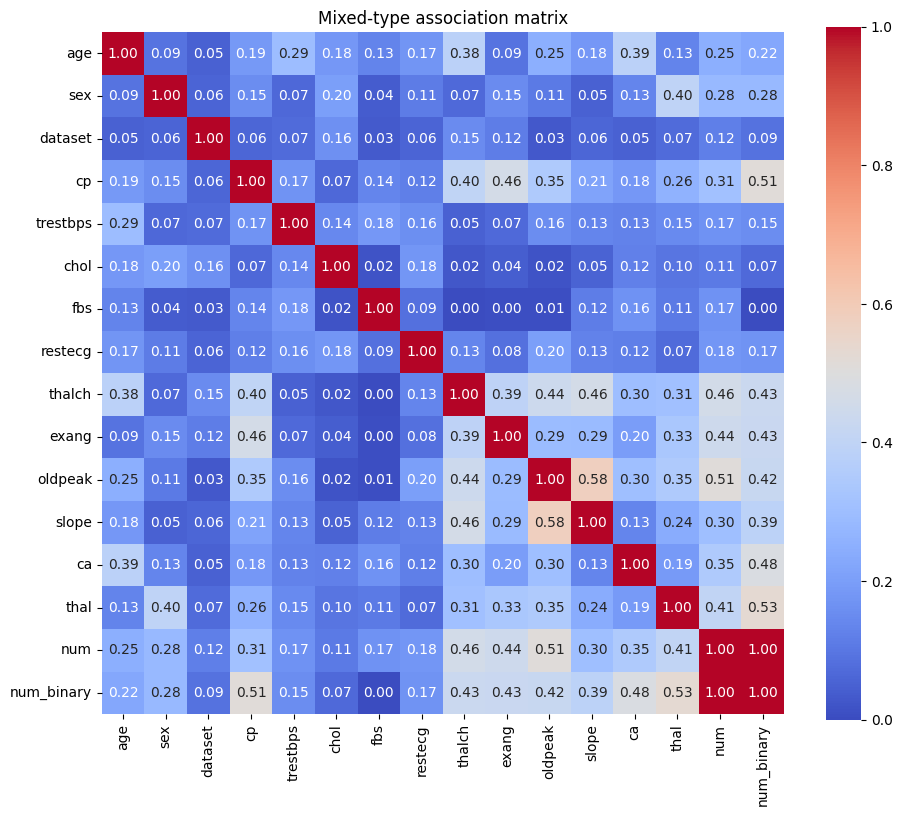

In [290]:
d = data.drop(columns="id", errors="ignore").copy()

def cramers_v(x, y):
    t = pd.crosstab(x, y)
    if t.shape[0] < 2 or t.shape[1] < 2:
        return np.nan
    chi2 = stats.chi2_contingency(t, correction=False)[0]
    return np.sqrt(chi2 / (t.to_numpy().sum() * (min(t.shape) - 1)))

def eta(cat, num):
    m = pd.concat([cat, num], axis=1).dropna()
    c, v = m.iloc[:, 0], m.iloc[:, 1]
    grand = v.mean()
    ss_between = sum(len(g) * (g.mean() - grand) ** 2 for _, g in v.groupby(c))
    ss_total = ((v - grand) ** 2).sum()
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else np.nan

cols = list(d.columns)
assoc = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols)

for i, a in enumerate(cols):
    for b in cols[i + 1:]:
        if a in num_cols and b in num_cols:
            val = abs(d[a].corr(d[b], method="spearman"))
        elif a in cat_cols and b in cat_cols:
            val = cramers_v(d[a], d[b])
        elif a in cat_cols:
            val = eta(d[a], d[b])
        else:
            val = eta(d[b], d[a])
        assoc.loc[a, b] = assoc.loc[b, a] = val

plt.figure(figsize=(11, 9))
sns.heatmap(assoc.astype(float), annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1, square=True)
plt.title("Mixed-type association matrix")
plt.show()

Use IQR to detect outliers:

In [291]:
iqr_outlier_flags = pd.DataFrame(
    False,
    index=data.index,
    columns=num_cols
)

iqr_summary = []

for col in num_cols:

    col_data = pd.to_numeric(
        data[col],
        errors="coerce"
    )

    q1 = col_data.quantile(0.25)
    q3 = col_data.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    flags = (
        (col_data < lower_bound) |
        (col_data > upper_bound)
    )

    iqr_outlier_flags[col] = flags

    iqr_summary.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower_bound,
        "Upper bound": upper_bound,
        "Potential outliers": flags.sum(),
        "Percentage (%)": flags.mean() * 100
    })

iqr_summary = pd.DataFrame(iqr_summary)

display(iqr_summary.round(4))

,Variable,Q1,Q3,IQR,Lower bound,Upper bound,Potential outliers,Percentage (%)
0,age,48.0,61.0,13.0,28.50,80.50,0,0.0000
1,trestbps,120.0,140.0,20.0,90.00,170.00,9,3.0100
2,chol,211.0,275.5,64.5,114.25,372.25,6,2.0067
3,thalch,132.5,165.5,33.0,83.00,215.00,1,0.3344
4,oldpeak,0.0,1.6,1.6,-2.40,4.00,5,1.6722


Show basic features for categorical values:

In [292]:
for col in cat_cols:

    print("\n" + "=" * 60)
    print(f"{col}")
    print("=" * 60)

    frequency_table = data[col].value_counts(dropna=False).to_frame(
        name="Frequency"
    )

    frequency_table["Percentage (%)"] = (
        frequency_table["Frequency"] / len(data) * 100
    )

    display(frequency_table)


sex


,Frequency,Percentage (%)
sex,,
Male,203,67.892977
Female,96,32.107023



dataset


,Frequency,Percentage (%)
dataset,,
Cleveland,297,99.331104
Hungary,1,0.334448
VA Long Beach,1,0.334448



cp


...

,Frequency,Percentage (%)
thal,,
normal,164,54.849498
reversable defect,117,39.130435
fixed defect,18,6.020067



num


,Frequency,Percentage (%)
num,,
0,160,53.511706
1,56,18.729097
2,35,11.705686
3,35,11.705686
4,13,4.347826



num_binary


,Frequency,Percentage (%)
num_binary,,
0,160,53.511706
1,139,46.488294


# Hypothesis testing

Set alpha value

In [293]:
alpha = 0.05

def output_separator(func):
  def wrap(*args, **kwargs):
    print("-"*80)
    output = func(*args, **kwargs)
    print("-"*80)
    return output
  return wrap

Shapiro-Wilk test for normality of distribution

In [294]:
@output_separator
def shapiro_test(column):
  x = data[column].dropna()
  stat, p_value = stats.shapiro(x)
  print(f"H0: variable \"{column}\" is normally distributed")
  print(f"H1: variable \"{column}\" is not normally distributed")
  print(f"Test statistic:{stat:.3f}; p-value:{p_value:.3f}")
  print(f"{p_value} {'<' if p_value<alpha else '>'} {alpha} -> p_value {'<' if p_value<alpha else '>'} alpha")
  print(f"H0 is rejected. Variable \"{column}\" is not normally distributed" if p_value<alpha else f"H0 is accepted. Variable \"{column}\" is normally distributed")

# test if cholesterol levels among participants have normal distribution
shapiro_test("chol")
# test if age is normally distributed
shapiro_test("age")

--------------------------------------------------------------------------------
H0: variable "chol" is normally distributed
H1: variable "chol" is not normally distributed
Test statistic:0.952; p-value:0.000
2.7188274417106217e-08 < 0.05 -> p_value < alpha
H0 is rejected. Variable "chol" is not normally distributed
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
H0: variable "age" is normally distributed
H1: variable "age" is not normally distributed
Test statistic:0.986; p-value:0.006
0.0063009140490814354 < 0.05 -> p_value < alpha
H0 is rejected. Variable "age" is not normally distributed
--------------------------------------------------------------------------------


Population proportion test

In [295]:
@output_separator
def population_proportion_test(column, target, p0, alt):
  col_data = data[column].dropna().astype(int)
  success = (col_data == target).sum()
  n = len(col_data)
  z_stat, p_value = proportions_ztest(count=success, nobs=n, value=p0, alternative=alt)
  alt_statement = {"two-sided": "is not", "smaller": "is smaller than", "larger": "is larger than"}
  print(f"H0: p = {p0}")
  print(f"H1: p {alt_statement[alt]} {p0}")
  print(f"Test statistic: {z_stat:.3f}; p-value: {p_value:.3f}; alternative: {alt}",)
  print(f"{p_value} {'<' if p_value<alpha else '>'} {alpha} -> p_value {'<' if p_value<alpha else '>'} alpha")
  print(f"H0 is {'rejected' if p_value<alpha else 'accepted'}. The proportion of {target} in variable {column} {alt_statement[alt] if p_value<alpha else 'is'} {p0}")

#test if half of the population is healthy
population_proportion_test("num", 0, 0.5, alt="two-sided")


--------------------------------------------------------------------------------
H0: p = 0.5
H1: p is not 0.5
Test statistic: 1.217; p-value: 0.223; alternative: two-sided
0.22342626120113696 > 0.05 -> p_value > alpha
H0 is accepted. The proportion of 0 in variable num is 0.5
--------------------------------------------------------------------------------


Spearman's rank two variable correlation test

In [296]:
@output_separator
def spearman_rank(column1, column2):
  zero_invalid = ["age", "chol", "trestbps", "thalch"]
  sub = data[[column1, column2]].replace({column: {0: np.nan} for column in [column1, column2] if column in zero_invalid}).dropna()
  rho, p_value = stats.spearmanr(sub[column1], sub[column2])
  print(f"H0: {column1} and {column2} are independent")
  print(f"H1: {column1} and {column2} are dependent")
  print(f"Test statistic:{rho:.3f}; p-value:{p_value:.3f}")
  print(f"{p_value} {'<' if p_value<alpha else '>'} {alpha} -> p_value {'<' if p_value<alpha else '>'} alpha")
  print(f"H0 is {'rejected' if p_value<alpha else 'accepted'}. Continuous variables {column1} and {column2} {"" if p_value<alpha else "do not "}have a significant relationship")

spearman_rank("age", "chol")

--------------------------------------------------------------------------------
H0: age and chol are independent
H1: age and chol are dependent
Test statistic:0.184; p-value:0.001
0.0014313995546301186 < 0.05 -> p_value < alpha
H0 is rejected. Continuous variables age and chol have a significant relationship
--------------------------------------------------------------------------------


Chi-square (χ²) test of independence of two categorical variables

In [297]:
@output_separator
def chi_square_independece(column1, column2):
  ind_table = pd.crosstab(data[column1], data[column2])
  chi2_stat, p_value, dof, expected = stats.chi2_contingency(ind_table)
  print(f"H0: {column1} and {column2} are independent")
  print(f"H1: {column1} and {column2} are dependent")
  print(f"Test statistic:{chi2_stat:.3f}; p-value:{p_value:.3f}")
  print(f"p_value{'<' if p_value<alpha else '>'}alpha")
  print(f"H0 is {'rejected' if p_value<alpha else 'accepted'}. Categorical variables {column1} and {column2} {"" if p_value<alpha else "do not "}have a significant relationship")

# test if there is a dependence between fasting blood sugar > 120 mg/dl and heart disease
chi_square_independece("cp", "num_binary")

--------------------------------------------------------------------------------
H0: cp and num_binary are independent
H1: cp and num_binary are dependent
Test statistic:78.913; p-value:0.000
p_value<alpha
H0 is rejected. Categorical variables cp and num_binary have a significant relationship
--------------------------------------------------------------------------------


# Regression

Define global parameters:

In [298]:
ALPHA = 0.05
RANDOM_STATE = 42
TEST_SIZE = 0.20

### Linear regression
Prepare multiple linear regression model data

In [299]:
multiple_lr_cols = ["age", "sex", "exang", "oldpeak", "slope", "ca", "num_binary", "thalch"]
multiple_lr_data = data[multiple_lr_cols].copy()

multiple_lr_data["sex"] = multiple_lr_data["sex"].map({"Male": 1, "Female": 0})
multiple_lr_data["slope"] = multiple_lr_data["slope"].map({"downsloping": 0, "flat": 1, "upsloping": 2})
display(multiple_lr_data.head())
multiple_lr_data.info()

,age,sex,exang,oldpeak,slope,ca,num_binary,thalch
0,63,1,0.0,2.3,0,0.0,0,150.0
1,67,1,1.0,1.5,1,3.0,1,108.0
2,67,1,1.0,2.6,1,2.0,1,129.0
3,37,1,0.0,3.5,0,0.0,0,187.0
4,41,0,0.0,1.4,2,0.0,0,172.0


<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 748
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         299 non-null    int64  
 1   sex         299 non-null    int64  
 2   exang       299 non-null    float64
 3   oldpeak     299 non-null    float64
 4   slope       299 non-null    int64  
 5   ca          299 non-null    float64
 6   num_binary  299 non-null    int64  
 7   thalch      299 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 21.0 KB


Correlation matrix and significance testing


age vs. sex
H0: ρ = 0
H1: ρ ≠ 0
Correlation coefficient (r) = -0.0937
p-value = 0.105907
p-value >= 0.05: Do not reject H0. There is insufficient evidence of a statistically significant correlation.

age vs. exang
H0: ρ = 0
H1: ρ ≠ 0
Correlation coefficient (r) = 0.0925
p-value = 0.110422
p-value >= 0.05: Do not reject H0. There is insufficient evidence of a statistically significant correlation.

age vs. oldpeak
H0: ρ = 0
H1: ρ ≠ 0
Correlation coefficient (r) = 0.1959
p-value = 0.000657
p-value < 0.05: Reject H0. The correlation is statistically significant.

age vs. slope
H0: ρ = 0
H1: ρ ≠ 0
Correlation coefficient (r) = -0.1575
p-value = 0.006336
p-value < 0.05: Reject H0. The correlation is statistically significant.

age vs. ca
H0: ρ = 0
H1: ρ ≠ 0
Correlation coefficient (r) = 0.3628
p-value = 0.000000
p-value < 0.05: Reject H0. The correlation is statistically significant.

age vs. num_binary
H0: ρ = 0
H1: ρ ≠ 0
Correlation coefficient (r) = 0.2235
p-value = 0.000097
p-value < 0

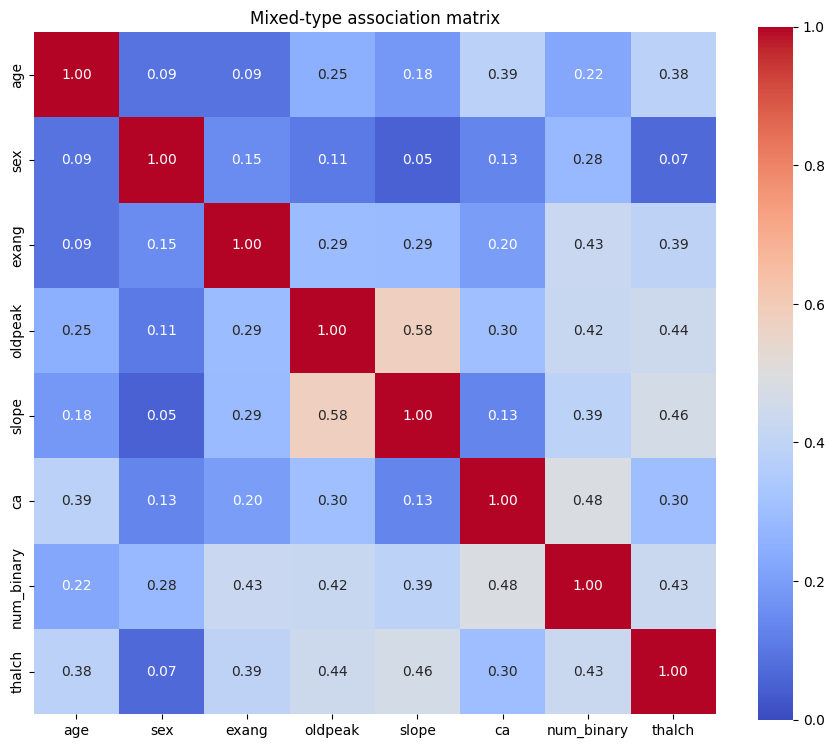

In [300]:
multiple_lr_cols = list(multiple_lr_data.columns)
assoc = pd.DataFrame(np.eye(len(multiple_lr_cols)), index=multiple_lr_cols, columns=multiple_lr_cols)

for i, a in enumerate(multiple_lr_cols):
    for b in multiple_lr_cols[i + 1:]:
        if a in num_cols and b in num_cols:
            val = abs(multiple_lr_data[a].corr(multiple_lr_data[b], method="spearman"))
        elif a in cat_cols and b in cat_cols:
            val = cramers_v(multiple_lr_data[a], multiple_lr_data[b])
        elif a in cat_cols:
            val = eta(multiple_lr_data[a], multiple_lr_data[b])
        else:
            val = eta(multiple_lr_data[b], multiple_lr_data[a])
        assoc.loc[a, b] = assoc.loc[b, a] = val


columns = assoc.columns

correlations = []

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):

        var1 = columns[i]
        var2 = columns[j]

        pair_data = multiple_lr_data[[var1, var2]]

        r, p_value = stats.pearsonr(
            pair_data[var1],
            pair_data[var2]
        )

        print(
            f"\n{var1} vs. {var2}"
        )

        print("H0: ρ = 0")
        print("H1: ρ ≠ 0")

        print(
            f"Correlation coefficient (r) = {r:.4f}"
        )

        print(
            f"p-value = {p_value:.6f}"
        )

        if p_value < ALPHA:
            print(
                f"p-value < {ALPHA}: Reject H0. "
                "The correlation is statistically significant."
            )
        else:
            print(
                f"p-value >= {ALPHA}: Do not reject H0. "
                "There is insufficient evidence of a statistically significant correlation."
            )

        correlations.append({
            "Variable 1": var1,
            "Variable 2": var2,
            "Correlation (r)": r,
            "p-value": p_value,
            "Significant": (
                "Yes" if p_value < ALPHA else "No"
            )
        })



plt.figure(figsize=(11, 9))
sns.heatmap(assoc.astype(float), annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1, square=True)
plt.title("Mixed-type association matrix")
plt.show()

Split data into validation and training, and fit a linear regression line

In [301]:
x = multiple_lr_data[["age", "oldpeak", "ca", "exang", "num_binary", "slope"]]
y = multiple_lr_data["thalch"]

X_train, X_test, Y_train, Y_test = train_test_split(
    x,
    y,
    test_size = TEST_SIZE,
    random_state = RANDOM_STATE
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
print(f"Training proportion: "f"{len(X_train) / len(multiple_lr_data):.0%}")
print(f"Testing proportion: "f"{len(X_test) / len(multiple_lr_data):.0%}")

multiple_lr_model = LinearRegression()
multiple_lr_model.fit(X_train, Y_train)

print("Multiple Linear Regression model")
print("Coefficients:")
print(f"Intercept = { multiple_lr_model.intercept_:.6f}")
print(f"age coefficient = {multiple_lr_model.coef_[0]:.6f}")
print(f"oldpeak coefficient = "f"{multiple_lr_model.coef_[1]:.6f}")
print(f"ca coefficient = "f"{multiple_lr_model.coef_[2]:.6f}")
print(f"exang coefficient = "f"{multiple_lr_model.coef_[3]:.6f}")
print(f"num_binary coefficient = "f"{multiple_lr_model.coef_[4]:.6f}")
print(f"slope coefficient = "f"{multiple_lr_model.coef_[5]:.6f}")
print("Estimated regression equation:")
print("thalch = "f"{multiple_lr_model.intercept_:.4f} + " + ' + '.join([f"{multiple_lr_model.coef_[index]} × {variable}" for index, variable in enumerate(["age", "oldpeak", "ca", "exang", "num_binary", "slope"])]))

X_train_sm = sm.add_constant(X_train)
ols_multiple_model = sm.OLS(Y_train, X_train_sm).fit()

Training observations: 239
Testing observations: 60
Training proportion: 80%
Testing proportion: 20%
Multiple Linear Regression model
Coefficients:
Intercept = 184.274136
age coefficient = -0.736845
oldpeak coefficient = 0.226206
ca coefficient = 0.242322
exang coefficient = -11.697957
num_binary coefficient = -9.149550
slope coefficient = 9.024383
Estimated regression equation:
thalch = 184.2741 + -0.7368448972538886 × age + 0.22620620767103983 × oldpeak + 0.24232170209688197 × ca + -11.697957027139939 × exang + -9.149549564051991 × num_binary + 9.024383168030488 × slope


Generate predictions from the test dataset

In [302]:
y_pred_multiple = multiple_lr_model.predict(X_test)

multiple_predictions = X_test.copy()

multiple_predictions["Actual"] = Y_test.values
multiple_predictions["Predicted"] = (y_pred_multiple)
multiple_predictions["Residual"] = (multiple_predictions["Actual"]- multiple_predictions["Predicted"])

display(multiple_predictions.head(15))

,age,oldpeak,ca,exang,num_binary,slope,Actual,Predicted,Residual
285,58,4.4,3.0,0.0,1,0,140.0,134.109855,5.890145
269,42,0.0,0.0,0.0,0,2,150.0,171.375417,-21.375417
165,57,0.0,0.0,1.0,0,2,168.0,148.624787,19.375213
9,53,3.1,0.0,1.0,1,0,155.0,125.075089,29.924911
77,51,1.5,1.0,0.0,0,2,142.0,165.325444,-23.325444
282,55,2.0,1.0,1.0,1,1,130.0,132.619278,-2.619278
94,63,0.0,0.0,0.0,0,2,172.0,155.901674,16.098326
110,61,1.0,0.0,1.0,1,1,146.0,127.729680,18.270320
5,56,0.8,0.0,0.0,0,2,178.0,161.240553,16.759447
175,57,1.2,1.0,1.0,1,1,88.0,130.964623,-42.964623


Calculate model performance statistics

In [303]:
def calculate_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    nonzero_mask = y_true != 0

    if nonzero_mask.sum() == 0:
        return np.nan

    return np.mean(
        np.abs(
            (y_true[nonzero_mask] - y_pred[nonzero_mask])
            / y_true[nonzero_mask]
        )
    ) * 100

mae_multiple = mean_absolute_error(Y_test, y_pred_multiple)
mse_multiple = mean_squared_error(Y_test, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
r_squared_multiple = r2_score(Y_test, y_pred_multiple)
mape_multiple = calculate_mape(Y_test, y_pred_multiple)

multiple_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "MAPE (%)",
        "R-squared"
    ],
    "Value": [
        mae_multiple,
        mse_multiple,
        rmse_multiple,
        mape_multiple,
        r_squared_multiple
    ]
})

display(multiple_metrics)

,Metric,Value
0,MAE,15.315450
1,MSE,381.487041
2,RMSE,19.531693
3,MAPE (%),10.752590
4,R-squared,0.260818


Calculate model F-score

In [304]:
print("t-test for individual regression coefficients")

for index, (variable, p_value) in enumerate(ols_multiple_model.pvalues.items()):
  print(variable)
  print(f"H0: b{index} = 0")
  print(f"H0: b{index} = 0")
  print(f"p-value = {p_value}")
  print(f"{'Reject' if p_value < ALPHA else 'Accept'} H0."f" {variable} {"is" if p_value < ALPHA else "is not"} a statistically significant predictor")

print("\nF-test for the overall regression model")

print("H0: b1 = b2 = 0")
print("H1: At least one b coefficient is not equal to 0")

f_stat_multiple = ols_multiple_model.fvalue
f_p_value_multiple = ols_multiple_model.f_pvalue

print(f"F-statistic = {f_stat_multiple:.4f}")
print(f"p-value = {f_p_value_multiple:.6f}")

if f_p_value_multiple < ALPHA:
    print(
        f"p-value < {ALPHA}: Reject H0. "
        "The regression model is statistically significant."
    )
else:
    print(
        f"p-value >= {ALPHA}: Do not reject H0. "
        "There is insufficient evidence that the regression model is statistically significant."
    )

t-test for individual regression coefficients
const
H0: b0 = 0
H0: b0 = 0
p-value = 2.5439680262966822e-55
Reject H0. const is a statistically significant predictor
age
H0: b1 = 0
H0: b1 = 0
p-value = 1.9222294547021377e-07
Reject H0. age is a statistically significant predictor
oldpeak
H0: b2 = 0
H0: b2 = 0
p-value = 0.8622418490638054
Accept H0. oldpeak is not a statistically significant predictor
ca
H0: b3 = 0
H0: b3 = 0
p-value = 0.866469142129654
Accept H0. ca is not a statistically significant predictor
exang
H0: b4 = 0
H0: b4 = 0
p-value = 4.617266965795392e-05
Reject H0. exang is a statistically significant predictor
num_binary
H0: b5 = 0
H0: b5 = 0
p-value = 0.0032285855496431894
Reject H0. num_binary is a statistically significant predictor
slope
H0: b6 = 0
H0: b6 = 0
p-value = 0.0002337383950220181
Reject H0. slope is a statistically significant predictor

F-test for the overall regression model
H0: b1 = b2 = 0
H1: At least one b coefficient is not equal to 0
F-statistic = 2

Plot the regression line

Text(0.5, 1.0, 'Actual vs. Predicted Values — Multiple Linear Regression')

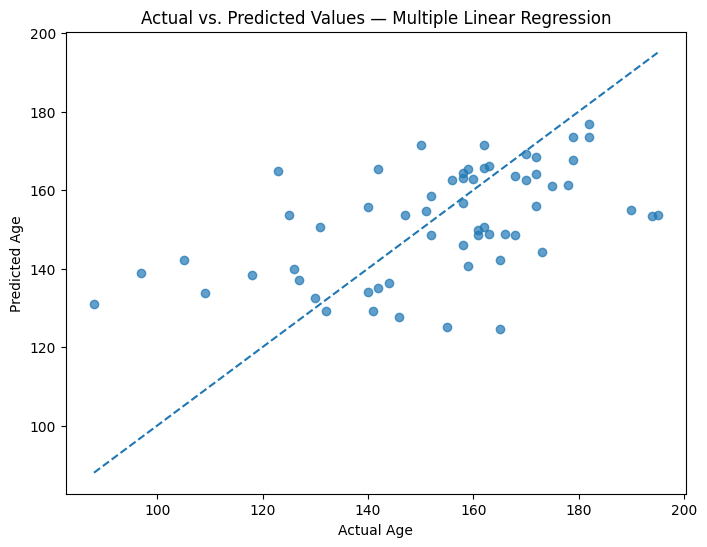

In [305]:
plt.figure(figsize=(8, 6))

plt.scatter(
    multiple_predictions["Actual"],
    multiple_predictions["Predicted"],
    alpha=0.7
)

min_value = min(
    multiple_predictions["Actual"].min(),
    multiple_predictions["Predicted"].min()
)

max_value = max(
    multiple_predictions["Actual"].max(),
    multiple_predictions["Predicted"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Actual vs. Predicted Values — Multiple Linear Regression")

### Logistic regression
Prepare logistic regression model data:

In [306]:
logistic_prediction_variables = [
    "age",
    "sex",
    "exang",
    "thalch",
    "cp",
    "oldpeak",
    "num_binary"
]
predictor_cols = [
    "age",
    "sex"
    "exang",
    "thalch",
    "cp",
    "oldpeak",
]
logistic_data = data[logistic_prediction_variables].copy()
logistic_data["sex"] = logistic_data["sex"].map({"Male": 1, "Female": 0})
logistic_data = pd.get_dummies(logistic_data, columns=["cp"], drop_first=True, dtype=int)

predictor_cols = list(logistic_data.columns.drop("num_binary"))
print("Target variable distribution:")


display(logistic_data.head())

Target variable distribution:


,age,sex,exang,thalch,oldpeak,num_binary,cp_atypical angina,cp_non-anginal,cp_typical angina
0,63,1,0.0,150.0,2.3,0,0,0,1
1,67,1,1.0,108.0,1.5,1,0,0,0
2,67,1,1.0,129.0,2.6,1,0,0,0
3,37,1,0.0,187.0,3.5,0,0,1,0
4,41,0,0.0,172.0,1.4,0,1,0,0


Split data into validation and training dataset

In [307]:
X = logistic_data[predictor_cols]
Y = logistic_data["num_binary"].astype(int)

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=Y
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining target proportions:")
print(Y_train.value_counts(normalize=True))

print("\nTesting target proportions:")
print(Y_test.value_counts(normalize=True))

Training observations: 239
Testing observations: 60

Training target proportions:
num_binary
0    0.535565
1    0.464435
Name: proportion, dtype: float64

Testing target proportions:
num_binary
0    0.533333
1    0.466667
Name: proportion, dtype: float64


Fit a logistic regression model

In [308]:
logistic_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)


logistic_model.fit(X_train, Y_train)

Y_prob = logistic_model.predict_proba(X_test)[:, 1]

classification_threshold = 0.50

Y_pred = (Y_prob >= classification_threshold).astype(int)

print("Logistic regression model fitted successfully.")
print(f"Classification threshold = {classification_threshold}")

logistic_intercept = logistic_model.intercept_[0]

logistic_coefficients = logistic_model.coef_[0]

logistic_coefficients_table = pd.DataFrame({
    "Variable": predictor_cols,
    "Coefficient": logistic_coefficients,
    "Odds_Ratio": np.exp(logistic_coefficients)
})

display(logistic_coefficients_table)

print(f"Intercept = {logistic_intercept:.6f}")

print("\nLogistic regression equation (log-odds scale):")

equation = f"logit(p) = {logistic_intercept:.6f}"

for variable, coefficient in zip(
    predictor_cols,
    logistic_coefficients
):
    sign = "+" if coefficient >= 0 else "-"
    equation += (
        f" {sign} "
        f"{abs(coefficient):.6f} × {variable}"
    )

print(equation)

Logistic regression model fitted successfully.
Classification threshold = 0.5


,Variable,Coefficient,Odds_Ratio
0,age,0.037708,1.038428
1,sex,1.240897,3.458714
2,exang,0.672018,1.958184
3,thalch,-0.015012,0.985100
4,oldpeak,0.670447,1.955111
5,cp_atypical angina,-0.919671,0.398650
6,cp_non-anginal,-1.590734,0.203776
7,cp_typical angina,-1.449246,0.234747


Intercept = -1.079610

Logistic regression equation (log-odds scale):
logit(p) = -1.079610 + 0.037708 × age + 1.240897 × sex + 0.672018 × exang - 0.015012 × thalch + 0.670447 × oldpeak - 0.919671 × cp_atypical angina - 1.590734 × cp_non-anginal - 1.449246 × cp_typical angina


Generate predictions from the test set

In [309]:
logistic_predictions = X_test.copy()

logistic_predictions["Actual_num"] = Y_test.values

logistic_predictions["Predicted_probability_yes"] = Y_prob

logistic_predictions["Predicted_num"] = Y_pred

logistic_predictions["Predicted_label"] = (
    logistic_predictions["Predicted_num"]
    .map({
        0: "No",
        1: "Yes"
    })
)

display(logistic_predictions.head(15))

,age,sex,exang,thalch,oldpeak,cp_atypical angina,cp_non-anginal,cp_typical angina,Actual_num,Predicted_probability_yes,Predicted_num,Predicted_label
295,41,1,0.0,182.0,0.0,1,0,0,0,0.125147,0,No
242,49,0,0.0,163.0,0.0,0,0,0,0,0.157241,0,No
90,66,1,0.0,151.0,0.4,0,0,0,0,0.657316,1,Yes
102,57,0,0.0,159.0,0.0,0,0,0,0,0.211287,0,No
67,54,1,0.0,165.0,1.6,0,1,0,0,0.310560,0,No
255,42,0,0.0,173.0,0.0,0,1,0,0,0.024514,0,No
113,43,0,1.0,136.0,3.0,0,0,0,1,0.765584,1,Yes
238,49,0,0.0,162.0,0.0,1,0,0,0,0.070204,0,No
66,60,1,0.0,155.0,3.0,0,1,0,1,0.626561,1,Yes
200,50,0,0.0,159.0,0.0,0,0,0,0,0.170634,0,No


Display the confusion matrix

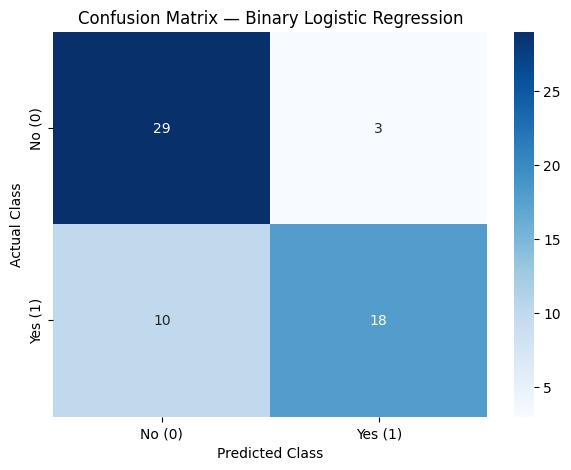

In [310]:
cm = confusion_matrix(
    Y_test,
    Y_pred,
    labels=[0, 1]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No (0)", "Yes (1)"],
    yticklabels=["No (0)", "Yes (1)"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title("Confusion Matrix — Binary Logistic Regression")

plt.show()

Calculate classification regression metrics

In [311]:
accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred, zero_division=0)
recall = recall_score(Y_test, Y_pred, zero_division=0)
f1 = f1_score(Y_test, Y_pred, zero_division=0)
auc = roc_auc_score(Y_test, Y_prob)

classification_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

display(classification_metrics)

,Metric,Value
0,Accuracy,0.783333
1,Precision,0.857143
2,Recall,0.642857
3,F1-score,0.734694
4,ROC-AUC,0.928571


# Classification with Decision Trees

In [312]:

binary_tree_cols = ["age", "thalch", "oldpeak", "ca", "num_binary"]
binary_tree_data = data[binary_tree_cols].copy()

X = binary_tree_data[["age", "thalch", "oldpeak", "ca"]]
Y = binary_tree_data["num_binary"]

X_encoded = pd.get_dummies(X, dtype=int)

x_train, x_test, y_train, y_test = train_test_split(X_encoded, Y, test_size=0.3, random_state=42)


In [313]:
def decision_tree(max_depth=None, min_samples_leaf=1):
  classifier = DecisionTreeClassifier(random_state=42, max_depth=max_depth, min_samples_leaf=min_samples_leaf)
  classifier.fit(x_train, y_train)
  return classifier

def plot_tree(tree_classifier):
  dot = export_graphviz(
    tree_classifier, feature_names=x_train.columns,
    class_names=["No disease", "Disease"],
    filled=True, rounded=True, proportion=True, impurity=False
  )
  dot = dot.replace("digraph Tree {", 'digraph Tree {\nsize="13";\n', 1)
  display(graphviz.Source(dot))



depths = [2, 4, 5, 7, None]
min_samples_leafs=[1, 2, 3, 4, 7]
trees = dict()
for depth in depths:
  for min_samples_leaf in min_samples_leafs:
    trees[(depth, min_samples_leaf)] = decision_tree(depth, min_samples_leaf)
    y_pred = trees[(depth, min_samples_leaf)].predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Depth {depth}, min samples leaf {min_samples_leaf} accuracy:", accuracy)




Depth 2, min samples leaf 1 accuracy: 0.7
Depth 2, min samples leaf 2 accuracy: 0.7
Depth 2, min samples leaf 3 accuracy: 0.7
Depth 2, min samples leaf 4 accuracy: 0.7
Depth 2, min samples leaf 7 accuracy: 0.7
Depth 4, min samples leaf 1 accuracy: 0.6888888888888889
Depth 4, min samples leaf 2 accuracy: 0.7
Depth 4, min samples leaf 3 accuracy: 0.6888888888888889
Depth 4, min samples leaf 4 accuracy: 0.7333333333333333
Depth 4, min samples leaf 7 accuracy: 0.7333333333333333
Depth 5, min samples leaf 1 accuracy: 0.6666666666666666
Depth 5, min samples leaf 2 accuracy: 0.6777777777777778
Depth 5, min samples leaf 3 accuracy: 0.6888888888888889
Depth 5, min samples leaf 4 accuracy: 0.7222222222222222
Depth 5, min samples leaf 7 accuracy: 0.7333333333333333
Depth 7, min samples leaf 1 accuracy: 0.6333333333333333
Depth 7, min samples leaf 2 accuracy: 0.6888888888888889
Depth 7, min samples leaf 3 accuracy: 0.6666666666666666
Depth 7, min samples leaf 4 accuracy: 0.7111111111111111
Depth 7

In [314]:

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

for (depth, min_samples_leaf),tree in trees.items():
  results = cross_validate(
      tree, X_encoded, Y,
      cv=cv, scoring=scoring,
      return_train_score=True,
  )
  print(f"Tree of detpth {depth} and min samples leaf {min_samples_leaf} metrics:")
  summary = pd.DataFrame({
      "test_mean": {m: results[f"test_{m}"].mean() for m in scoring},
      "test_std":  {m: results[f"test_{m}"].std()  for m in scoring},
      "train_mean": {m: results[f"train_{m}"].mean() for m in scoring},
  }).round(3)
  print(summary)

Tree of detpth 2 and min samples leaf 1 metrics:
                   test_mean  test_std  train_mean
accuracy               0.712     0.078       0.755
balanced_accuracy      0.710     0.076       0.755
precision              0.726     0.144       0.748
recall                 0.690     0.153       0.747
f1                     0.685     0.092       0.736
roc_auc                0.780     0.080       0.824
Tree of detpth 2 and min samples leaf 2 metrics:
                   test_mean  test_std  train_mean
accuracy               0.712     0.078       0.755
balanced_accuracy      0.710     0.076       0.755
precision              0.726     0.144       0.748
recall                 0.690     0.153       0.747
f1                     0.685     0.092       0.736
roc_auc                0.780     0.080       0.824
Tree of detpth 2 and min samples leaf 3 metrics:
                   test_mean  test_std  train_mean
accuracy               0.712     0.078       0.755
balanced_accuracy      0.710     0.07

Output tree structure

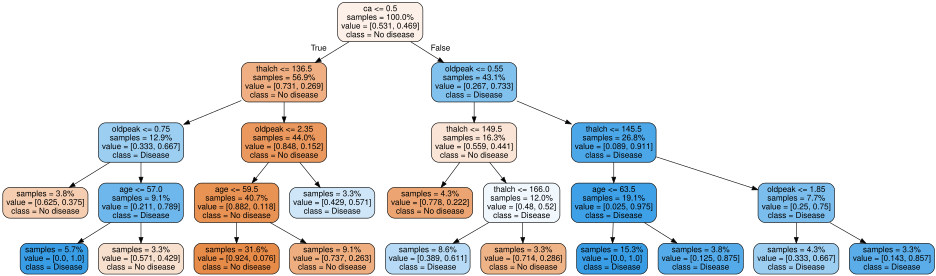

In [315]:
plot_tree(trees[(4,7)])

Output decision rules

In [316]:
tree_rules = export_text(trees[(4,7)], feature_names=["age", "thalch", "oldpeak", "ca"])
print(tree_rules)

|--- ca <= 0.50
|   |--- thalch <= 136.50
|   |   |--- oldpeak <= 0.75
|   |   |   |--- class: 0
|   |   |--- oldpeak >  0.75
|   |   |   |--- age <= 57.00
|   |   |   |   |--- class: 1
|   |   |   |--- age >  57.00
|   |   |   |   |--- class: 0
|   |--- thalch >  136.50
|   |   |--- oldpeak <= 2.35
|   |   |   |--- age <= 59.50
|   |   |   |   |--- class: 0
|   |   |   |--- age >  59.50
|   |   |   |   |--- class: 0
|   |   |--- oldpeak >  2.35
|   |   |   |--- class: 1
|--- ca >  0.50
|   |--- oldpeak <= 0.55
|   |   |--- thalch <= 149.50
|   |   |   |--- class: 0
|   |   |--- thalch >  149.50
|   |   |   |--- thalch <= 166.00
|   |   |   |   |--- class: 1
|   |   |   |--- thalch >  166.00
|   |   |   |   |--- class: 0
|   |--- oldpeak >  0.55
|   |   |--- thalch <= 145.50
|   |   |   |--- age <= 63.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  63.50
|   |   |   |   |--- class: 1
|   |   |--- thalch >  145.50
|   |   |   |--- oldpeak <= 1.85
|   |   |   |   |--- class: 1
|

# Clustering

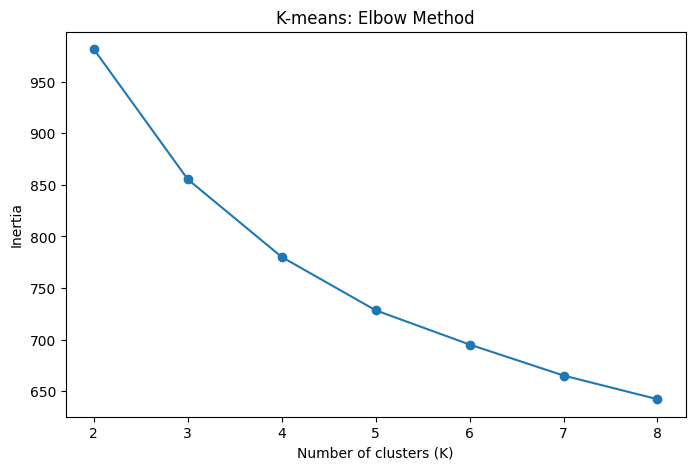

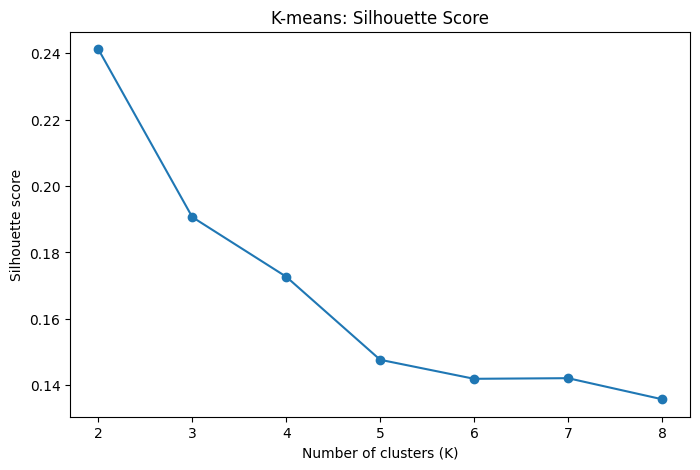

In [317]:
features = [
    "oldpeak",
    "age",
    "thalch",
    "exang",
    "cp",
    "slope",
    "thal",
    "ca"
]

clustering_data = data[features].copy()
X = pd.get_dummies(clustering_data, columns=["thal", "cp", "slope"], dtype=int)


X_scaled = RobustScaler().fit_transform(X)

inertias = []
silhouette_scores = []

K_values = range(2, 9)


for k in K_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
    )

    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)

    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

plt.figure(figsize=(8, 5))

plt.plot(K_values, inertias, marker="o")

plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("K-means: Elbow Method")

plt.figure(figsize=(8, 5))

plt.plot(K_values, silhouette_scores, marker="o")

plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.title("K-means: Silhouette Score")

plt.show()



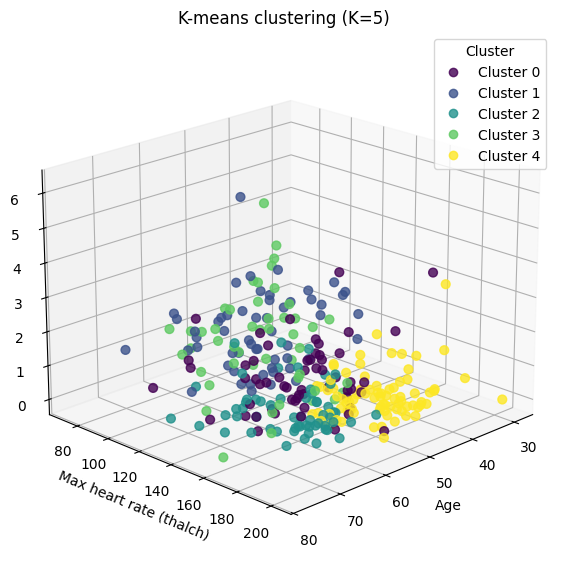

num,0,1,2,3,4,Total
kmeans_cluster,,,,,,
0,39,13,2,2,2,58
1,5,17,15,14,4,55
2,44,10,4,1,0,59
3,3,7,13,18,7,48
4,69,9,1,0,0,79
Total,160,56,35,35,13,299


In [318]:
K = 5

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
)

clustering_data["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    clustering_data["age"],
    clustering_data["thalch"],
    clustering_data["oldpeak"],
    c=clustering_data["kmeans_cluster"],
    cmap="viridis",
    s=40,
    alpha=0.8,
)

ax.set_xlabel("Age")
ax.set_ylabel("Max heart rate (thalch)")
ax.set_zlabel("ST depression (oldpeak)")
ax.set_title("K-means clustering (K=5)")

handles, _ = sc.legend_elements()
ax.legend(handles, [f"Cluster {i}" for i in range(K)], title="Cluster")

ax.view_init(elev=20, azim=45)
plt.show()

ct = pd.crosstab(clustering_data["kmeans_cluster"], data["num"],
                 margins=True, margins_name="Total")
display(ct)


